# Exploratory Data Analysis

In [1]:
# Import Python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read dataset into dataframe
df = pd.read_csv('data/flash_floods_ky_2015_2025.csv')

In [3]:
# Read first rows of dataset
df.head()

,EVENT_ID,CZ_NAME_STR,BEGIN_LOCATION,BEGIN_DATE,BEGIN_TIME,EVENT_TYPE,MAGNITUDE,TOR_F_SCALE,DEATHS_DIRECT,INJURIES_DIRECT,...,END_AZIMUTH,END_LOCATION,END_DATE,END_TIME,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EVENT_NARRATIVE,EPISODE_NARRATIVE
0,564702,JEFFERSON CO.,SMYRNA,4/3/2015,348,Flash Flood,,,0,0,...,N,SMYRNA,4/3/2015,348,38.1500,-85.6600,38.1536,-85.6547,Law enforcement reported several water rescues...,A stalled frontal boundary across the area bro...
1,564703,JEFFERSON CO.,NEWBURG,4/3/2015,354,Flash Flood,,,0,0,...,WSW,NEWBURG,4/3/2015,354,38.1600,-85.7000,38.1633,-85.6969,Law enforcement reported evacuations at 6111 G...,A stalled frontal boundary across the area bro...
2,564704,ANDERSON CO.,LAWRENCEBURG,4/3/2015,400,Flash Flood,,,0,0,...,ESE,LAWRENCEBURG,4/3/2015,400,38.0229,-84.8866,38.0243,-84.8836,Emergency Management reported several roads cl...,A stalled frontal boundary across the area bro...
3,564706,SPENCER CO.,ELK CREEK,4/3/2015,400,Flash Flood,,,0,0,...,NNW,ELK CREEK,4/3/2015,400,38.0994,-85.3742,38.1038,-85.3727,State officials reported numerous water rescue...,A stalled frontal boundary across the area bro...
4,564705,JEFFERSON CO.,LOUISVILLE,4/3/2015,400,Flash Flood,,,0,0,...,SE,LOUISVILLE,4/3/2015,400,38.2300,-85.7800,38.2296,-85.7792,Law enforcement reported a road closure near 1...,A stalled frontal boundary across the area bro...


In [4]:
# Read last rows of dataset
df.tail()

,EVENT_ID,CZ_NAME_STR,BEGIN_LOCATION,BEGIN_DATE,BEGIN_TIME,EVENT_TYPE,MAGNITUDE,TOR_F_SCALE,DEATHS_DIRECT,INJURIES_DIRECT,...,END_AZIMUTH,END_LOCATION,END_DATE,END_TIME,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EVENT_NARRATIVE,EPISODE_NARRATIVE
1752,1297632,SPENCER CO.,WILSONVILLE,10/7/2025,1203,Flash Flood,,,0,0,...,NE,WATERFORD,10/7/2025,1303,38.1018,-85.4225,38.0623,-85.4013,There was water and debris over Plum Ridge Road.,As a couple of cold fronts moved through the L...
1753,1297629,JEFFERSON CO.,MINOR LANE HGTS,10/7/2025,1400,Flash Flood,,,0,0,...,NNW,MINOR LANE HGTS,10/7/2025,1500,38.1448,-85.7398,38.1446,-85.7372,Two men were standing on a rock with their lim...,As a couple of cold fronts moved through the L...
1754,1295858,FAYETTE CO.,(LEX)BLU GRS FLD LEX,10/7/2025,1430,Flash Flood,,,0,0,...,SW,SOUTH ELKHORN,10/7/2025,1630,38.0251,-84.5896,37.9979,-84.5823,Bowman Mill Road between Old Harrodsburg Road ...,As a couple of cold fronts moved through the L...
1755,1295859,FAYETTE CO.,YARNALLTON,10/7/2025,1433,Flash Flood,,,0,0,...,NW,YARNALLTON,10/7/2025,1633,38.1192,-84.6021,38.1434,-84.6502,Leestown Road between Dolan Lane and the Scott...,As a couple of cold fronts moved through the L...
1756,1295860,FAYETTE CO.,VILEY,10/7/2025,1436,Flash Flood,,,0,0,...,S,VILEY,10/7/2025,1636,38.0760,-84.5525,38.0748,-84.5509,Alexandria Drive between the Old Frankfort Pik...,As a couple of cold fronts moved through the L...


In [5]:
# Check data type and missing values
df.info()

print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   EVENT_ID             1757 non-null   int64  
 1   CZ_NAME_STR          1757 non-null   object 
 2   BEGIN_LOCATION       1757 non-null   object 
 3   BEGIN_DATE           1757 non-null   object 
 4   BEGIN_TIME           1757 non-null   int64  
 5   EVENT_TYPE           1757 non-null   object 
 6   MAGNITUDE            1757 non-null   object 
 7   TOR_F_SCALE          1757 non-null   object 
 8   DEATHS_DIRECT        1757 non-null   int64  
 9   INJURIES_DIRECT      1757 non-null   int64  
 10  DAMAGE_PROPERTY_NUM  1757 non-null   int64  
 11  DAMAGE_CROPS_NUM     1757 non-null   int64  
 12  STATE_ABBR           1757 non-null   object 
 13  CZ_TIMEZONE          1757 non-null   object 
 14  MAGNITUDE_TYPE       1757 non-null   object 
 15  EPISODE_ID           1757 non-null   i

In [6]:
# See the dimensions of the dataset
df.shape

(1757, 38)

In [7]:
# Find categorical variables using .select_dtypes()
df.select_dtypes(include='object').columns

Index(['CZ_NAME_STR', 'BEGIN_LOCATION', 'BEGIN_DATE', 'EVENT_TYPE',
       'MAGNITUDE', 'TOR_F_SCALE', 'STATE_ABBR', 'CZ_TIMEZONE',
       'MAGNITUDE_TYPE', 'CZ_TYPE', 'WFO', 'SOURCE', 'FLOOD_CAUSE',
       'TOR_LENGTH', 'TOR_WIDTH', 'BEGIN_AZIMUTH', 'END_AZIMUTH',
       'END_LOCATION', 'END_DATE', 'EVENT_NARRATIVE', 'EPISODE_NARRATIVE'],
      dtype='object')

In [8]:
# Explore value counts for categorial variables
df.value_counts(subset=['FLOOD_CAUSE']),
df.value_counts(subset=['CZ_NAME_STR'])

print(df['FLOOD_CAUSE'].value_counts())
print(df['CZ_NAME_STR'].value_counts())

FLOOD_CAUSE
Heavy Rain                      1756
Heavy Rain / Tropical System       1
Name: count, dtype: int64
CZ_NAME_STR
JEFFERSON CO.     92
PIKE CO.          44
SIMPSON CO.       39
BELL CO.          36
FLOYD CO.         36
                  ..
WOODFORD CO.       3
WAYNE CO.          3
LIVINGSTON CO.     2
ROBERTSON CO.      2
LYON CO.           2
Name: count, Length: 120, dtype: int64


In [9]:
# Explore numberical columns
df.describe()

,EVENT_ID,BEGIN_TIME,DEATHS_DIRECT,INJURIES_DIRECT,DAMAGE_PROPERTY_NUM,DAMAGE_CROPS_NUM,EPISODE_ID,CZ_FIPS,INJURIES_INDIRECT,DEATHS_INDIRECT,BEGIN_RANGE,END_RANGE,END_TIME,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON
count,1.757000e+03,1757.000000,1757.000000,1757.000000,1.757000e+03,1757.000000,1757.000000,1757.000000,1757.0,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000
mean,8.876687e+05,1335.211155,0.036426,0.009106,2.426549e+04,575.281730,145983.779169,118.640296,0.0,0.000569,1.286101,1.347621,1344.060330,37.602618,-85.139033,37.601395,-85.138703
std,2.194641e+05,630.683357,0.504913,0.358634,1.712214e+05,23857.141834,34467.116399,69.186638,0.0,0.023857,1.630638,1.617724,673.556341,0.611858,1.722825,0.609159,1.725535
min,5.583240e+05,0.000000,0.000000,0.000000,0.000000e+00,0.000000,93070.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,36.507000,-89.348400,36.500000,-89.245600
25%,6.911560e+05,830.000000,0.000000,0.000000,0.000000e+00,0.000000,115140.000000,59.000000,0.0,0.000000,0.620000,0.660000,830.000000,37.080000,-86.279100,37.089800,-86.273400
50%,8.973370e+05,1500.000000,0.000000,0.000000,0.000000e+00,0.000000,147970.000000,111.000000,0.0,0.000000,1.080000,1.100000,1500.000000,37.607800,-84.882600,37.611100,-84.867100
75%,1.049118e+06,1833.000000,0.000000,0.000000,1.000000e+03,0.000000,172563.000000,181.000000,0.0,0.000000,1.730000,1.740000,1900.000000,38.110000,-83.781400,38.101000,-83.780600
max,1.304116e+06,2359.000000,16.000000,15.000000,3.500000e+06,1000000.000000,207860.000000,239.000000,0.0,1.000000,47.680000,46.970000,2359.000000,39.100000,-82.063600,39.115200,-82.067500


In [10]:
# Filter rows using .loc[] ,.iloc[] and/or boolean indexing
df.loc[df['CZ_NAME_STR'] == 'Kentucky']
df.iloc[0:5]

,EVENT_ID,CZ_NAME_STR,BEGIN_LOCATION,BEGIN_DATE,BEGIN_TIME,EVENT_TYPE,MAGNITUDE,TOR_F_SCALE,DEATHS_DIRECT,INJURIES_DIRECT,...,END_AZIMUTH,END_LOCATION,END_DATE,END_TIME,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EVENT_NARRATIVE,EPISODE_NARRATIVE
0,564702,JEFFERSON CO.,SMYRNA,4/3/2015,348,Flash Flood,,,0,0,...,N,SMYRNA,4/3/2015,348,38.1500,-85.6600,38.1536,-85.6547,Law enforcement reported several water rescues...,A stalled frontal boundary across the area bro...
1,564703,JEFFERSON CO.,NEWBURG,4/3/2015,354,Flash Flood,,,0,0,...,WSW,NEWBURG,4/3/2015,354,38.1600,-85.7000,38.1633,-85.6969,Law enforcement reported evacuations at 6111 G...,A stalled frontal boundary across the area bro...
2,564704,ANDERSON CO.,LAWRENCEBURG,4/3/2015,400,Flash Flood,,,0,0,...,ESE,LAWRENCEBURG,4/3/2015,400,38.0229,-84.8866,38.0243,-84.8836,Emergency Management reported several roads cl...,A stalled frontal boundary across the area bro...
3,564706,SPENCER CO.,ELK CREEK,4/3/2015,400,Flash Flood,,,0,0,...,NNW,ELK CREEK,4/3/2015,400,38.0994,-85.3742,38.1038,-85.3727,State officials reported numerous water rescue...,A stalled frontal boundary across the area bro...
4,564705,JEFFERSON CO.,LOUISVILLE,4/3/2015,400,Flash Flood,,,0,0,...,SE,LOUISVILLE,4/3/2015,400,38.2300,-85.7800,38.2296,-85.7792,Law enforcement reported a road closure near 1...,A stalled frontal boundary across the area bro...


In [11]:
# Sort values using .sort_values()
df.sort_values(by='BEGIN_DATE', ascending=True)

,EVENT_ID,CZ_NAME_STR,BEGIN_LOCATION,BEGIN_DATE,BEGIN_TIME,EVENT_TYPE,MAGNITUDE,TOR_F_SCALE,DEATHS_DIRECT,INJURIES_DIRECT,...,END_AZIMUTH,END_LOCATION,END_DATE,END_TIME,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EVENT_NARRATIVE,EPISODE_NARRATIVE
1208,1004586,BREATHITT CO.,WHICK,1/1/2022,900,Flash Flood,,,0,0,...,WNW,LITTLE,1/1/2022,1115,37.4180,-83.3872,37.4343,-83.3833,Water was reported inside homes in the communi...,The second warmest December on record for East...
1203,1004929,ADAIR CO.,COBURG,1/1/2022,520,Flash Flood,,,0,0,...,N,COBURG,1/1/2022,720,37.2000,-85.3300,37.2028,-85.3300,Flash flooding occurred in Coburg. Damage amou...,"During New Year's Eve into New Year's Day, act..."
1204,1004346,FLOYD CO.,ARKANSAS,1/1/2022,757,Flash Flood,,,0,0,...,S,COLLIVER,1/1/2022,1145,37.5829,-82.7376,37.5922,-82.7306,Reports that water rescues were being performe...,The second warmest December on record for East...
1205,1005229,PIKE CO.,BELFRY,1/1/2022,817,Flash Flood,,,0,0,...,ESE,LECKIEVILLE,1/1/2022,1145,37.6158,-82.2808,37.6250,-82.2853,Water is reported to be in homes in the Belfry...,The second warmest December on record for East...
1206,1004352,BREATHITT CO.,CANOE,1/1/2022,830,Flash Flood,,,0,0,...,NNW,CANOE,1/1/2022,1115,37.4486,-83.4520,37.4565,-83.4522,A report came in that water rescues were being...,The second warmest December on record for East...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,773419,MENIFEE CO.,ROTHWELL,9/9/2018,1656,Flash Flood,,,0,0,...,N,ROTHWELL,9/9/2018,1906,37.9700,-83.7000,37.9709,-83.7011,A local media outlet reported water flowing ac...,"A slow moving low pressure system, in combinat..."
652,773420,ESTILL CO.,RAVENNA,9/9/2018,1825,Flash Flood,,,0,0,...,NE,PRYSE,9/9/2018,1855,37.6900,-83.9500,37.6944,-83.8559,Dispatch reported water flowing over several r...,"A slow moving low pressure system, in combinat..."
653,773422,POWELL CO.,WALTERSVILLE,9/9/2018,1835,Flash Flood,,,0,0,...,SSW,WALTERSVILLE,9/9/2018,2055,37.8600,-83.9400,37.8582,-83.9385,Water was observed rushing across Adams Ridges...,"A slow moving low pressure system, in combinat..."
649,783660,JESSAMINE CO.,UNION MILLS,9/9/2018,1441,Flash Flood,,,0,0,...,NNE,UNION MILLS,9/9/2018,1511,37.9100,-84.5000,37.9123,-84.4958,Mackey Pike near Hickman Creek was closed due ...,"On September 5, 2018, the remnants of Tropical..."


In [12]:
# Rename columns using .rename()
df.rename(columns={'CZ_NAME_STR': 'COUNTY_NAME'}, inplace=True)

print(df.columns.tolist())

['EVENT_ID', 'COUNTY_NAME', 'BEGIN_LOCATION', 'BEGIN_DATE', 'BEGIN_TIME', 'EVENT_TYPE', 'MAGNITUDE', 'TOR_F_SCALE', 'DEATHS_DIRECT', 'INJURIES_DIRECT', 'DAMAGE_PROPERTY_NUM', 'DAMAGE_CROPS_NUM', 'STATE_ABBR', 'CZ_TIMEZONE', 'MAGNITUDE_TYPE', 'EPISODE_ID', 'CZ_TYPE', 'CZ_FIPS', 'WFO', 'INJURIES_INDIRECT', 'DEATHS_INDIRECT', 'SOURCE', 'FLOOD_CAUSE', 'TOR_LENGTH', 'TOR_WIDTH', 'BEGIN_RANGE', 'BEGIN_AZIMUTH', 'END_RANGE', 'END_AZIMUTH', 'END_LOCATION', 'END_DATE', 'END_TIME', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON', 'EVENT_NARRATIVE', 'EPISODE_NARRATIVE']


In [13]:
# Drop columns using .drop()
df.drop(columns=['MAGNITUDE', 'MAGNITUDE_TYPE', 'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH'], inplace=True)

print(df.columns.tolist())

['EVENT_ID', 'COUNTY_NAME', 'BEGIN_LOCATION', 'BEGIN_DATE', 'BEGIN_TIME', 'EVENT_TYPE', 'DEATHS_DIRECT', 'INJURIES_DIRECT', 'DAMAGE_PROPERTY_NUM', 'DAMAGE_CROPS_NUM', 'STATE_ABBR', 'CZ_TIMEZONE', 'EPISODE_ID', 'CZ_TYPE', 'CZ_FIPS', 'WFO', 'INJURIES_INDIRECT', 'DEATHS_INDIRECT', 'SOURCE', 'FLOOD_CAUSE', 'BEGIN_RANGE', 'BEGIN_AZIMUTH', 'END_RANGE', 'END_AZIMUTH', 'END_LOCATION', 'END_DATE', 'END_TIME', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON', 'EVENT_NARRATIVE', 'EPISODE_NARRATIVE']


In [14]:
# Fix data types using .astype()
df = df.astype({'BEGIN_DATE': 'datetime64[ns]'})
df = df.astype({'END_DATE': 'datetime64[ns]'})
df = df.astype({'EVENT_ID': 'string'})
df = df.astype({'BEGIN_TIME': 'string'})
df = df.astype({'END_TIME': 'string'})
df = df.astype({'EPISODE_ID': 'string'})
df = df.astype({'CZ_FIPS': 'string'})
df = df.astype({'EVENT_NARRATIVE': 'string'})
df = df.astype({'EPISODE_NARRATIVE': 'string'})

print(df.dtypes)

EVENT_ID               string[python]
COUNTY_NAME                    object
BEGIN_LOCATION                 object
BEGIN_DATE             datetime64[ns]
BEGIN_TIME             string[python]
EVENT_TYPE                     object
DEATHS_DIRECT                   int64
INJURIES_DIRECT                 int64
DAMAGE_PROPERTY_NUM             int64
DAMAGE_CROPS_NUM                int64
STATE_ABBR                     object
CZ_TIMEZONE                    object
EPISODE_ID             string[python]
CZ_TYPE                        object
CZ_FIPS                string[python]
WFO                            object
INJURIES_INDIRECT               int64
DEATHS_INDIRECT                 int64
SOURCE                         object
FLOOD_CAUSE                    object
BEGIN_RANGE                   float64
BEGIN_AZIMUTH                  object
END_RANGE                     float64
END_AZIMUTH                    object
END_LOCATION                   object
END_DATE               datetime64[ns]
END_TIME    

In [15]:
# Identify missing values using .isnull() and/or .notnull()
df.isnull().sum()

EVENT_ID               0
COUNTY_NAME            0
BEGIN_LOCATION         0
BEGIN_DATE             0
BEGIN_TIME             0
EVENT_TYPE             0
DEATHS_DIRECT          0
INJURIES_DIRECT        0
DAMAGE_PROPERTY_NUM    0
DAMAGE_CROPS_NUM       0
STATE_ABBR             0
CZ_TIMEZONE            0
EPISODE_ID             0
CZ_TYPE                0
CZ_FIPS                0
WFO                    0
INJURIES_INDIRECT      0
DEATHS_INDIRECT        0
SOURCE                 0
FLOOD_CAUSE            0
BEGIN_RANGE            0
BEGIN_AZIMUTH          0
END_RANGE              0
END_AZIMUTH            0
END_LOCATION           0
END_DATE               0
END_TIME               0
BEGIN_LAT              0
BEGIN_LON              0
END_LAT                0
END_LON                0
EVENT_NARRATIVE        8
EPISODE_NARRATIVE      0
dtype: int64

In [16]:
# View rows with missing values
df[df.isnull().any(axis=1)] 

print(df[df['EVENT_NARRATIVE'].isnull()])

     EVENT_ID    COUNTY_NAME      BEGIN_LOCATION BEGIN_DATE BEGIN_TIME  \
1448  1102154     GRAVES CO.               LOWES 2023-07-19         56   
1449  1102165   CALLOWAY CO.          LYNN GROVE 2023-07-19        356   
1450  1102183     FULTON CO.          ANNA LYNNE 2023-07-19        430   
1451  1102181   CARLISLE CO.           ARLINGTON 2023-07-19        445   
1452  1102170    HICKMAN CO.              BEULAH 2023-07-19        538   
1453  1102172  MCCRACKEN CO.                OAKS 2023-07-19        625   
1454  1102178    BALLARD CO.               KEVIL 2023-07-19        629   
1455  1102185   MARSHALL CO.  GILBERTSVILLE ARPT 2023-07-19        830   

       EVENT_TYPE  DEATHS_DIRECT  INJURIES_DIRECT  DAMAGE_PROPERTY_NUM  \
1448  Flash Flood              0                0              2000000   
1449  Flash Flood              0                0               500000   
1450  Flash Flood              0                0               100000   
1451  Flash Flood              0     

In [17]:
# Replace missing values in EVENT_NARRATIVE with "Unknown"
df["EVENT_NARRATIVE"] = df["EVENT_NARRATIVE"].fillna("Unknown")

print(df["EVENT_NARRATIVE"].isna().sum())

0


In [18]:
# Check for duplicate rows using .duplicated()
df.duplicated().sum()

np.int64(0)

In [19]:
# Create YEAR column
df["YEAR"] = df["BEGIN_DATE"].dt.year

df = df.astype({'YEAR': 'int64'})

print(df["YEAR"].value_counts())

YEAR
2015    237
2021    217
2025    207
2018    169
2020    165
2022    163
2016    156
2019    133
2023    121
2017    120
2024     69
Name: count, dtype: int64


In [20]:
df.describe()

,BEGIN_DATE,DEATHS_DIRECT,INJURIES_DIRECT,DAMAGE_PROPERTY_NUM,DAMAGE_CROPS_NUM,INJURIES_INDIRECT,DEATHS_INDIRECT,BEGIN_RANGE,END_RANGE,END_DATE,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,YEAR
count,1757,1757.000000,1757.000000,1.757000e+03,1757.000000,1757.0,1757.000000,1757.000000,1757.000000,1757,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000
mean,2020-03-08 10:33:32.066021376,0.036426,0.009106,2.426549e+04,575.281730,0.0,0.000569,1.286101,1.347621,2020-03-08 12:29:54.877632256,37.602618,-85.139033,37.601395,-85.138703,2019.759249
min,2015-04-03 00:00:00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,0.000000,0.000000,2015-04-03 00:00:00,36.507000,-89.348400,36.500000,-89.245600,2015.000000
25%,2017-05-27 00:00:00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,0.620000,0.660000,2017-05-27 00:00:00,37.080000,-86.279100,37.089800,-86.273400,2017.000000
50%,2020-05-25 00:00:00,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,1.080000,1.100000,2020-05-25 00:00:00,37.607800,-84.882600,37.611100,-84.867100,2020.000000
75%,2022-08-06 00:00:00,0.000000,0.000000,1.000000e+03,0.000000,0.0,0.000000,1.730000,1.740000,2022-08-06 00:00:00,38.110000,-83.781400,38.101000,-83.780600,2022.000000
max,2025-10-07 00:00:00,16.000000,15.000000,3.500000e+06,1000000.000000,0.0,1.000000,47.680000,46.970000,2025-10-07 00:00:00,39.100000,-82.063600,39.115200,-82.067500,2025.000000
std,NaN,0.504913,0.358634,1.712214e+05,23857.141834,0.0,0.023857,1.630638,1.617724,NaN,0.611858,1.722825,0.609159,1.725535,3.241000


In [21]:
# Use .groupby() to explore number of flash flooding events by county
county_counts = (
    df.groupby("COUNTY_NAME")
      .size()
      .reset_index(name="Total_Events")
      .sort_values("Total_Events", ascending=False)
)

print(county_counts.head(10))

       COUNTY_NAME  Total_Events
55   JEFFERSON CO.            92
97        PIKE CO.            44
106    SIMPSON CO.            39
6         BELL CO.            36
35       FLOYD CO.            36
78   MCCRACKEN CO.            30
17    CALLOWAY CO.            27
12   BREATHITT CO.            26
104      SCOTT CO.            25
44     GREENUP CO.            24


In [22]:
# Use .groupby() to explore total property damage by county
property_damage = (
    df.groupby("COUNTY_NAME")["DAMAGE_PROPERTY_NUM"]
      .sum()
      .reset_index()
      .sort_values("DAMAGE_PROPERTY_NUM", ascending=False)
)

print(property_damage.head(10))

      COUNTY_NAME  DAMAGE_PROPERTY_NUM
17   CALLOWAY CO.              3965000
57    JOHNSON CO.              3514000
21     CARTER CO.              2771750
82    MENIFEE CO.              2634500
75   MARSHALL CO.              2625000
37     FULTON CO.              2195000
41     GRAVES CO.              2120000
90   NICHOLAS CO.              2000000
63   LAWRENCE CO.              1628750
55  JEFFERSON CO.              1616000


In [23]:
# Use .groupby() to explore total deaths and injuries by county
human_impact = (
    df.groupby("COUNTY_NAME")[["DEATHS_DIRECT", "INJURIES_DIRECT"]]
      .sum()
      .reset_index()
      .sort_values("DEATHS_DIRECT", ascending=False)
)

print(human_impact.head(10))

      COUNTY_NAME  DEATHS_DIRECT  INJURIES_DIRECT
59      KNOTT CO.             16                0
12  BREATHITT CO.             10                0
96      PERRY CO.              7                0
57    JOHNSON CO.              4               15
66    LETCHER CO.              3                0
25       CLAY CO.              3                0
49       HART CO.              2                0
90   NICHOLAS CO.              2                0
36   FRANKLIN CO.              2                0
16   CALDWELL CO.              1                0


In [24]:
# Use .groupby() to explore how many flash flooding events were reported from each source
source_counts = (
    df.groupby("SOURCE")
      .size()
      .reset_index(name="Total_Events")
      .sort_values("Total_Events", ascending=False)
)

print(source_counts)

                    SOURCE  Total_Events
0          911 Call Center           378
8        Emergency Manager           365
16                  Public           228
10         Law Enforcement           192
2          Broadcast Media           143
20         Trained Spotter           122
6   Department of Highways            90
18          State Official            90
12            NWS Employee            40
9   Fire Department/Rescue            32
17            Social Media            19
1            Amateur Radio            17
5          County Official            12
3            COOP Observer             7
14               Newspaper             6
22         Utility Company             4
19            Storm Chaser             3
11                 Mesonet             3
15    Other Federal Agency             2
13        NWS Storm Survey             1
7          Drought Monitor             1
4                 CoCoRaHS             1
21                 Unknown             1


In [25]:
# Use .groupby() to explore the top 5 dates that had the most flash flooding events
date_counts = (
    df.groupby("BEGIN_DATE")
      .size()
      .reset_index(name="TOTAL_EVENTS")
      .sort_values("TOTAL_EVENTS", ascending=False)
)

print(date_counts.head(5))

    BEGIN_DATE  TOTAL_EVENTS
324 2025-02-15            61
20  2015-07-14            54
0   2015-04-03            51
271 2023-01-03            42
133 2019-02-23            41


In [26]:
# Use .groupby() to explore the counties and cities that experienced flash flooding events on the top 5 dates. Show the dates and the total number of events for each county on those dates.
top_dates = date_counts.head(5)["BEGIN_DATE"]
county_city_date_counts = (
    df[df["BEGIN_DATE"].isin(top_dates)]
      .groupby(["BEGIN_DATE", "COUNTY_NAME", "BEGIN_LOCATION"])
      .size()
      .reset_index(name="TOTAL_EVENTS")
      .sort_values(["BEGIN_DATE", "TOTAL_EVENTS"], ascending=[True, False])
)

print(county_city_date_counts)

    BEGIN_DATE  COUNTY_NAME BEGIN_LOCATION  TOTAL_EVENTS
8   2015-04-03   ESTILL CO.        CRYSTAL             2
13  2015-04-03    FLOYD CO.        BONANZA             2
17  2015-04-03  JACKSON CO.  CLOVER BOTTOM             2
37  2015-04-03     PIKE CO.      PIKEVILLE             2
42  2015-04-03  SPENCER CO.      ELK CREEK             2
..         ...          ...            ...           ...
227 2025-02-15   WARREN CO.  BOWLING GREEN             1
228 2025-02-15   WARREN CO.       BROWNING             1
229 2025-02-15   WARREN CO.         COHRON             1
230 2025-02-15  WEBSTER CO.           CLAY             1
232 2025-02-15  WEBSTER CO.          LUZON             1

[233 rows x 4 columns]


In [27]:
# Immport data into csv file
county_city_date_counts.to_csv("data/output/county_city_date_counts.csv", index=False)

In [28]:
# Sort values to determine which flash flooding events were the most expensive
highest_damage = df.sort_values("DAMAGE_PROPERTY_NUM", ascending=False)

print(highest_damage[
    ["BEGIN_DATE", "COUNTY_NAME", "DAMAGE_PROPERTY_NUM"]
].head(10))

     BEGIN_DATE    COUNTY_NAME  DAMAGE_PROPERTY_NUM
144  2015-07-13    JOHNSON CO.              3500000
989  2021-02-28   CALLOWAY CO.              2900000
472  2017-06-23     CARTER CO.              2300000
1466 2023-08-04     FULTON CO.              2000000
1139 2021-07-30    MENIFEE CO.              2000000
1448 2023-07-19     GRAVES CO.              2000000
316  2016-07-07   MARSHALL CO.              2000000
117  2015-07-07  MCCRACKEN CO.              1200000
33   2015-04-03    BULLITT CO.              1000000
1133 2021-07-30   NICHOLAS CO.              1000000


In [29]:
# Sort Values to determine which flash flooding events had the most injuries
most_injuries = df.sort_values("INJURIES_DIRECT", ascending=False)

print(most_injuries[
    ["BEGIN_DATE", "COUNTY_NAME", "INJURIES_DIRECT"]
].head(10))

     BEGIN_DATE     COUNTY_NAME  INJURIES_DIRECT
144  2015-07-13     JOHNSON CO.               15
903  2020-06-29  WASHINGTON CO.                1
0    2015-04-03   JEFFERSON CO.                0
1180 2021-08-30      MCLEAN CO.                0
1178 2021-08-30      SHELBY CO.                0
1177 2021-08-30        PIKE CO.                0
1176 2021-08-30        PIKE CO.                0
1175 2021-08-30        PIKE CO.                0
1174 2021-08-30        PIKE CO.                0
1173 2021-08-30        PIKE CO.                0


In [30]:
# Create a summary table for the following question: What were the causes of flash floods?
cause_table = (
    df.groupby("FLOOD_CAUSE")
      .size()
      .reset_index(name="Count")
      .sort_values("Count", ascending=False)
)

print(cause_table.head(10))

                    FLOOD_CAUSE  Count
0                    Heavy Rain   1756
1  Heavy Rain / Tropical System      1


In [31]:
# Create a summary table for the following question: What has been the total statewide impact of flash flooding in Kentucky from 2015-2025?
summary = pd.DataFrame({
    "Total Events": [len(df)],
    "Total Property Damage": [df["DAMAGE_PROPERTY_NUM"].sum()],
    "Total Deaths": [df["DEATHS_DIRECT"].sum()],
    "Total Injuries": [df["INJURIES_DIRECT"].sum()]
})

print(summary)

   Total Events  Total Property Damage  Total Deaths  Total Injuries
0          1757               42634460            64              16


In [32]:
# Create a summary table for the following question: How has reporting sources changed over time?
source_year = pd.crosstab(df["YEAR"], df["SOURCE"])

print(source_year)

SOURCE  911 Call Center  Amateur Radio  Broadcast Media  COOP Observer  \
YEAR                                                                     
2015                 12              1               22              0   
2016                 12              1               13              1   
2017                 15              1                8              3   
2018                 26             13               36              1   
2019                 39              0               16              0   
2020                 38              0               20              0   
2021                 72              0               16              1   
2022                 45              0                5              1   
2023                 34              0                3              0   
2024                 17              1                1              0   
2025                 68              0                3              0   

SOURCE  CoCoRaHS  County Official  De

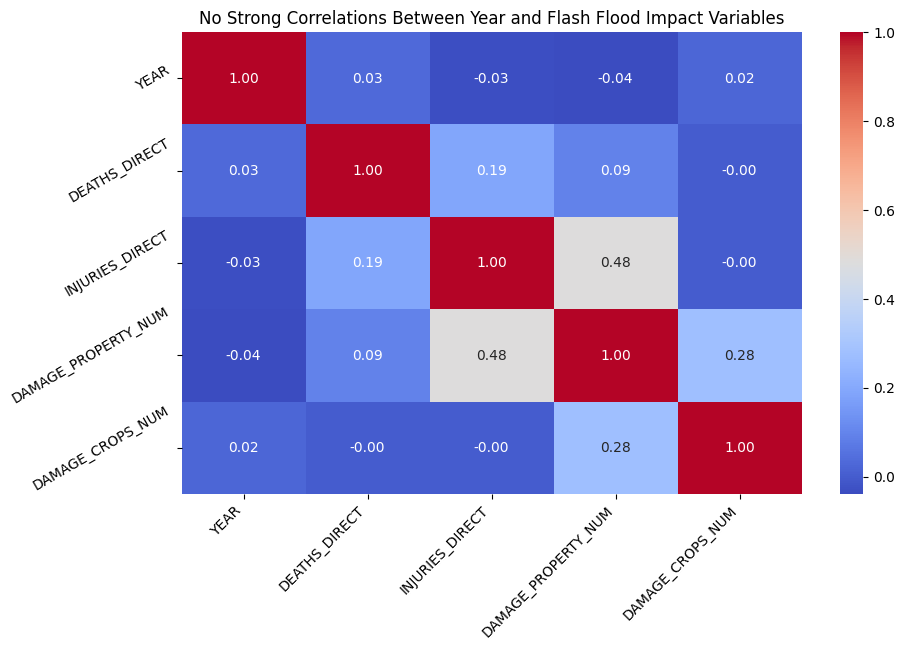

In [38]:
# Create a heatmap that shows correlations between numerical variables
cols = [
    "YEAR",
    "DEATHS_DIRECT",
    "INJURIES_DIRECT",
    "DAMAGE_PROPERTY_NUM",
    "DAMAGE_CROPS_NUM"
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("No Strong Correlations Between Year and Flash Flood Impact Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=30, va="center")

plt.show()

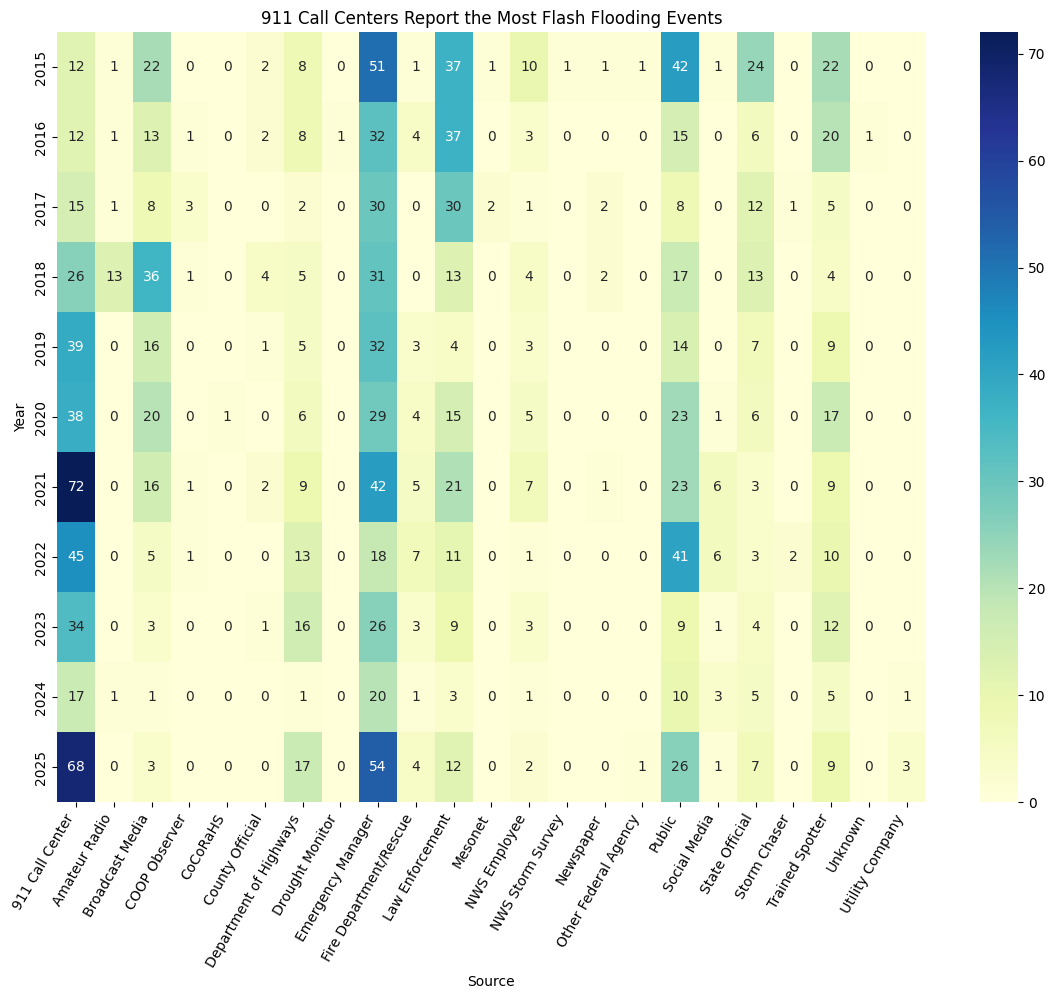

In [35]:
# Create a heatmap that shows correlations between years and sources
source_year = pd.crosstab(df["YEAR"], df["SOURCE"]) 

plt.figure(figsize=(14, 10))

sns.heatmap(
    source_year,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("911 Call Centers Report the Most Flash Flooding Events")
plt.xlabel("Source")
plt.ylabel("Year")
plt.xticks(rotation=60, ha="right")
plt.yticks()

plt.show()

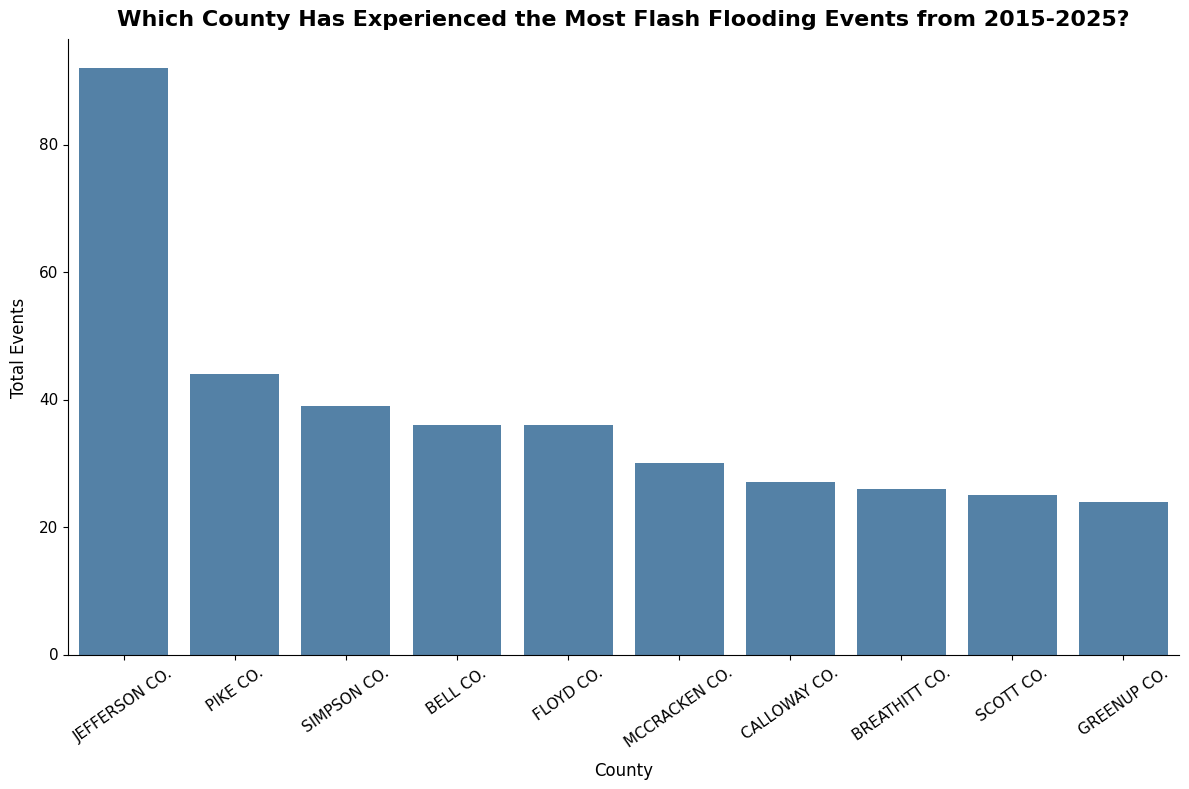

In [69]:
# Create a bar chart that shows the top 10 counties with the most flash flooding events
county_counts = (
    df.groupby("COUNTY_NAME")
      .size()
      .reset_index(name="Total_Events")
      .sort_values("Total_Events", ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=county_counts,
    x="COUNTY_NAME",
    y="Total_Events",
    color="steelblue"
)

plt.title(
    "Which County Has Experienced the Most Flash Flooding Events from 2015-2025?",
    fontsize=16,
    fontweight="bold",
    pad=10
)

plt.xlabel(
    "County",
    fontsize=12,
    labelpad=8
)

plt.ylabel(
    "Total Events",
    fontsize=12,
    labelpad=8
)

plt.xticks(
    rotation=35,
    ha="center",
    fontsize=11
)

plt.yticks(
    va="center",
    fontsize=11
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
!pip freeze > requirements.txt
print("Requirements file created successfully.")

Requirements file created successfully.
